In [ ]:
!pip install transformers

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
Notebook includes:
- Dataloading and preprocessing
- Model
- Training loops and functions

Adapted from: https://curiousily.com/posts/sentiment-analysis-with-bert-and-hugging-face-using-pytorch-and-python/

"""


import pandas as pd
import transformers
import torch
from transformers import AutoTokenizer, AutoModel
pd.set_option('display.max_colwidth', None)

from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
import torch.nn.functional as F

from collections import defaultdict
import numpy as np 

In [ ]:
#### utils.py

# load dataset
def read_data(path):
  df = pd.read_csv(path, sep='\t', lineterminator='\n', 
                        header=None, names=["sentiment", "aspect_category",
                                            "target_term", "time", "review"])
  df.review = df.review.apply(lambda x: x.strip("\r"))
  return df

def prepare_reviews(df):
  df["apsect_target"] = df.aspect_category + "#" + df.target_term
  df["y_true"] = df.sentiment.map({"positive": 2, "negative": 1, "neutral": 0})
  df["X"] = df.review + "[SEP]" + df.apsect_target
  return df[["X", "y_true"]]


def create_data_loader(df, tokenizer, batch_size, max_len=164):
  ds = ReviewDataset(
    reviews=df.X.to_numpy(),
    targets=df.y_true.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )
  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=4
  )

def split_dataframe(df, test_size=0.1):
  df_train, df_val = train_test_split(
  df,
  test_size=test_size,
  random_state=42)
  return df_train, df_val

# Dataloader

class ReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len=164):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len
  
  def __len__(self):
    return len(self.reviews)
  
  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    # padding = "longest" also an option
    encoding = self.tokenizer.encode_plus(
        review, 
        add_special_tokens=True, 
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors="pt",
        padding='max_length',
        max_length=self.max_len
        )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }


In [ ]:
### model.py

class BertAsc(nn.Module):
    """Full model"""
    def __init__(self, model_name="activebus/BERT_Review", n_classes=3):
        super(BertAsc, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(p=0.2)
        self.linear = nn.Linear(self.bert.config.hidden_size, n_classes)

    #############################################
    def forward(self, input_ids, attention_mask):
      output = self.bert(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      x = output["pooler_output"]
      x = self.dropout(x)
      x = self.linear(x)
  
      return F.softmax(x, dim=1)

In [ ]:
# train functions

def train_epoch(
    model, 
    data_loader, 
    loss_fn, 
    optimizer, 
    device, 
    scheduler, 
    n_examples):
    model = model.train()

    losses = []
    correct_predictions = 0
    
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )

      _, preds = torch.max(outputs, dim=1)
      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      scheduler.step()
      optimizer.zero_grad()
    
    return correct_predictions.double() / n_examples, np.mean(losses)


def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()

    losses = []
    correct_predictions = 0

    with torch.no_grad():
      for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask
        )
        _, preds = torch.max(outputs, dim=1)

        loss = loss_fn(outputs, targets)

        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses) 

MAIN

In [ ]:

# PARAMS
PATH = None # to define
PRETRAIN_MODEL = "activebus/BERT_Review"
BS = 10
EPOCHS = 7
MAX_LEN = 164

# load
device = torch.device("cuda")
df = read_data(PATH)
df = prepare_reviews(df)

# preprocess
tokenizer = AutoTokenizer.from_pretrained(PRETRAIN_MODEL)
df_train, df_val = split_dataframe(df, test_size = 0.1)
train_data_loader = create_data_loader(df_train, tokenizer, BS, 
                                        max_len= MAX_LEN)
val_data_loader = create_data_loader(df_val, tokenizer, BS,
                                      max_len = MAX_LEN)

# set upd training
model = BertAsc(model_name="activebus/BERT_Review", n_classes=3)
model = model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS
scheduler = transformers.get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
  )
loss_fn = nn.CrossEntropyLoss().to(device)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


In [ ]:
# training loop

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(
    model,
    train_data_loader,    
    loss_fn, 
    optimizer, 
    device, 
    scheduler, 
    len(df_train)
  )

  print(f'Train loss {train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(
    model,
    val_data_loader,
    loss_fn, 
    device, 
    len(df_val)
  )

  print(f'Val   loss {val_loss} accuracy {val_acc}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)

  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_acc

Epoch 1/7
----------


/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


Train loss 0.7803136758944568 accuracy 0.7965976331360947
Val   loss 0.6263774260878563 accuracy 0.9271523178807947

Epoch 2/7
----------
Train loss 0.6770003477440161 accuracy 0.8801775147928994
Val   loss 0.6731858998537064 accuracy 0.8741721854304636

Epoch 3/7
----------
Train loss 0.6627141548430219 accuracy 0.8949704142011834
Val   loss 0.6806911379098892 accuracy 0.8609271523178808

Epoch 4/7
----------
Train loss 0.6456021429861293 accuracy 0.9090236686390533
Val   loss 0.6826972663402557 accuracy 0.8609271523178808

Epoch 5/7
----------
Train loss 0.6458956025102559 accuracy 0.908284023668639
Val   loss 0.6703902222216129 accuracy 0.8741721854304636

Epoch 6/7
----------
Train loss 0.6405913400299409 accuracy 0.9134615384615384
Val   loss 0.669427402317524 accuracy 0.8741721854304636

Epoch 7/7
----------
Train loss 0.6392666324973106 accuracy 0.9149408284023668
Val   loss 0.6638956442475319 accuracy 0.8807947019867549



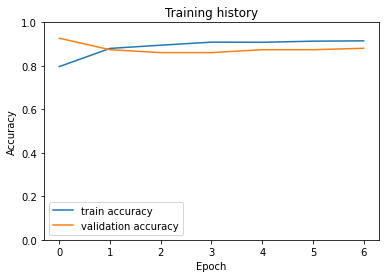

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);